# Imports

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Charger, observer et comprendre le dataset

In [2]:
dataset = pd.read_csv('credit.csv')
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


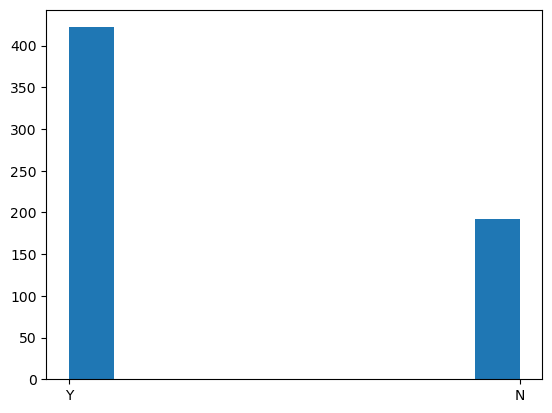

In [4]:
plt.hist(dataset['Loan_Status']);

In [5]:
X = dataset.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = dataset['Loan_Status']

# Afficher les données manquantes

In [6]:
X.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
dtype: int64

# Transformer les données catégorielles en données numériques

In [7]:
X.dtypes

Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
dtype: object

In [8]:
enc = OrdinalEncoder()

In [9]:
X[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']] = enc.fit_transform(X[['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']])

In [10]:
y = enc.fit_transform(y.values.reshape(-1, 1))

# Séparer le dataset en train et test

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Standardiser les données

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Traiter les données manquantes
Pour traiter les données manquantes, regarder `SimpleImputer` ou `KNNImputer`

In [13]:
imputer = KNNImputer(n_neighbors=5)
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

# Feature selection

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X.corr()
corr.style.background_gradient(cmap='coolwarm')

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
Gender,1.000000,0.369612,0.175970,0.049258,-0.009829,0.053989,0.083946,0.106947,-0.075117,0.016337,-0.024556
Married,0.369612,1.000000,0.343417,0.014223,0.001909,0.051332,0.077770,0.149519,-0.103810,0.004381,0.002918
Dependents,0.175970,0.343417,1.000000,0.059161,0.057867,0.118679,0.027259,0.163997,-0.100484,-0.050082,0.006828
Education,0.049258,0.014223,0.059161,1.000000,-0.012333,-0.140760,-0.062290,-0.171133,-0.078784,-0.081822,-0.065243
Self_Employed,-0.009829,0.001909,0.057867,-0.012333,1.000000,0.140826,-0.011152,0.123931,-0.037069,0.003883,-0.031214
ApplicantIncome,0.053989,0.051332,0.118679,-0.140760,0.140826,1.000000,-0.116605,0.570909,-0.045306,-0.014715,-0.009500
CoapplicantIncome,0.083946,0.077770,0.027259,-0.062290,-0.011152,-0.116605,1.000000,0.188619,-0.059878,-0.002056,0.010522
LoanAmount,0.106947,0.149519,0.163997,-0.171133,0.123931,0.570909,0.188619,1.000000,0.039447,-0.008433,-0.045792
Loan_Amount_Term,-0.075117,-0.103810,-0.100484,-0.078784,-0.037069,-0.045306,-0.059878,0.039447,1.000000,0.001470,-0.078748
Credit_History,0.016337,0.004381,-0.050082,-0.081822,0.003883,-0.014715,-0.002056,-0.008433,0.001470,1.000000,-0.001969


# Sélection automatique des variables corrélées avec Boruta

In [15]:
from boruta import BorutaPy
import warnings

In [16]:
rf = RandomForestClassifier()

boruta = BorutaPy(estimator=rf, n_estimators='auto', random_state=1, verbose=2)
# warnings.filterwarnings("ignore")

In [ ]:
boruta.fit(X_train, y_train)

In [18]:
ranking = pd.DataFrame({
    "Feature": X.columns,
    "Rank": boruta.ranking_
}).sort_values("Rank")

ranking

,Feature,Rank
9,Credit_History,1
7,LoanAmount,2
5,ApplicantIncome,3
6,CoapplicantIncome,4
8,Loan_Amount_Term,5
10,Property_Area,6
2,Dependents,7
1,Married,8
4,Self_Employed,9
3,Education,10


In [19]:
boruta.support_

array([False, False, False, False, False, False, False, False, False,
        True, False])

In [20]:
# selected_features = X.columns[boruta.support_]
X_train_selected = boruta.transform(X_train)
X_test_selected = boruta.transform(X_test)

In [21]:
boruta.support_weak_

array([False, False, False, False, False, False, False,  True, False,
       False, False])

In [22]:
ranking = pd.DataFrame({
    "Feature": X.columns,
    "Rank": boruta.ranking_
}).sort_values("Rank")

ranking

,Feature,Rank
9,Credit_History,1
7,LoanAmount,2
5,ApplicantIncome,3
6,CoapplicantIncome,4
8,Loan_Amount_Term,5
10,Property_Area,6
2,Dependents,7
1,Married,8
4,Self_Employed,9
3,Education,10


# **Evaluation des modèles**

In [23]:
resultats = []

# Régression logistique
Entrainer une régression logistique avec les hyper-paramètres par défaut

In [24]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
print(f'Train score: {clf.score(X_train, y_train)}')
print(f'Test score: {clf.score(X_test, y_test)}')

Train score: 0.8268839103869654
Test score: 0.7723577235772358


In [26]:
resultats.append([clf.__class__.__name__, "default", clf.score(X_train, y_train), clf.score(X_test, y_test)])

# KNN
Entrainer un KNN avec les hyper-paramètres par défaut. Puis, 
avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- k : 3, 5, 7, 9, 11,
- poids : uniform, distance,
- distances : euclidean, manhattan, minkowski

In [27]:
clf = KNeighborsClassifier()
clf.fit(X_train, y_train)
print(f'Train score: {clf.score(X_train, y_train)}')
print(f'Test score: {clf.score(X_test, y_test)}')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Train score: 0.8268839103869654
Test score: 0.7398373983739838


In [28]:
resultats.append([clf.__class__.__name__, "default", clf.score(X_train, y_train), clf.score(X_test, y_test)])

In [29]:
param_knn = {
    'n_neighbors' : [3, 5, 7, 9, 11],
    'weights' : ['uniform', 'distance'],
    'metric' : ['euclidean', 'manhattan', 'minkowski']
}

In [30]:
gridsearch = GridSearchCV(clf, param_knn, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neighbors\_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,estimator,KNeighborsClassifier()
,param_grid,"{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [31]:
gridsearch.best_params_

{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}

In [32]:
best_knn = gridsearch.best_estimator_
print(f'Train score: {best_knn.score(X_train, y_train)}')
print(f'Test score: {best_knn.score(X_test, y_test)}')

Train score: 0.8329938900203666
Test score: 0.7479674796747967


In [33]:
resultats.append([clf.__class__.__name__, gridsearch.best_params_, clf.score(X_train, y_train), clf.score(X_test, y_test)])

# SVM
Entrainer un SVM avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les paramètres suivants:
- C : 0.01, 0.1, 1, 10, 100,
- noyau : linear, poly, rbf, sigmoid,
- gamma : scale, auto, 0.001, 0.01, 0.1, 1,
- degrée du polynome : 2, 3, 4, 5

In [34]:
clf = SVC()
clf.fit(X_train, y_train)
print(f'Train score: {clf.score(X_train, y_train)}')
print(f'Test score: {clf.score(X_test, y_test)}')

Train score: 0.8370672097759674
Test score: 0.7723577235772358


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [35]:
resultats.append([clf.__class__.__name__, "default", clf.score(X_train, y_train), clf.score(X_test, y_test)])

In [36]:
param_svm = {
    'C': [0.01, 0.1, 1, 10, 100],
    'kernel' : ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma' : ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'degree' : [2, 3, 4, 5]
}

In [37]:
gridsearch = GridSearchCV(clf, param_svm, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 480 candidates, totalling 2400 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'degree': [2, 3, ...], 'gamma': ['scale', 'auto', ...], 'kernel': ['linear', 'poly', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [38]:
gridsearch.best_params_

{'C': 1, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}

In [39]:
best_svm = gridsearch.best_estimator_
print(f'Train score: {best_svm.score(X_train, y_train)}')
print(f'Test score: {best_svm.score(X_test, y_test)}')

Train score: 0.8207739307535642
Test score: 0.7804878048780488


In [40]:
resultats.append([clf.__class__.__name__, gridsearch.best_params_, clf.score(X_train, y_train), clf.score(X_test, y_test)])

# DecisionTree
Entrainer un arbre de décision avec les hyper-paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2

In [41]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
print(f'Train score: {clf.score(X_train, y_train)}')
print(f'Test score: {clf.score(X_test, y_test)}')

Train score: 1.0
Test score: 0.6991869918699187


In [42]:
resultats.append([clf.__class__.__name__, "default", clf.score(X_train, y_train), clf.score(X_test, y_test)])

In [43]:
param_dtc = {
    'criterion': ['gini', 'entropy'],
    'max_depth' : [None, 10, 20, 30, 40, 50],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 6],
    'max_features' : [None, 'sqrt', 'log2']
}

In [44]:
gridsearch = GridSearchCV(clf, param_dtc, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 576 candidates, totalling 2880 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [45]:
gridsearch.best_params_

{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 20}

In [46]:
best_dtc = gridsearch.best_estimator_
print(f'Train score: {best_dtc.score(X_train, y_train)}')
print(f'Test score: {best_dtc.score(X_test, y_test)}')

Train score: 0.7678207739307535
Test score: 0.6341463414634146


In [47]:
resultats.append([clf.__class__.__name__, gridsearch.best_params_, clf.score(X_train, y_train), clf.score(X_test, y_test)])

# RandomForest
Entrainer une forêt aléatoire avec les paramètres par défaut
Avec `GridSearchCV` ou `RandomizedSearchCV`, optimiser les hyper-paramètres. Utiliser une validation croisée de 5 splits. Vous explorerez les hyper-paramètres suivants:
- nombre d'arbres : 50, 100, 200, 300,
- critère : gini, entropy,
- profondeur maximale : None, 10, 20, 30, 40, 50,
- nombre minimum d'exemples par split : 2, 5, 10, 20,
- nombre minimum d'exemples par feuille : 1, 2, 4, 6,
- nombre de features maximum : None, sqrt, log2,
- remise des exemples : vrai, faux

In [48]:
clf = RandomForestClassifier()
clf.fit(X_train, y_train)
print(f'Train score: {clf.score(X_train, y_train)}')
print(f'Test score: {clf.score(X_test, y_test)}')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train score: 1.0
Test score: 0.7560975609756098


In [49]:
resultats.append([clf.__class__.__name__, "default", clf.score(X_train, y_train), clf.score(X_test, y_test)])

In [ ]:
param_rfc = {
    'n_estimators' : [50, 100, 200, 300],
    'criterion': ['gini', 'entropy'],
    'max_depth' : [None, 10, 20, 30, 40, 50],
    'min_samples_split' : [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 4, 6],
    'max_features' : [None, 'sqrt', 'log2'],
    'bootstrap' : [True, False]
}

In [53]:
gridsearch = GridSearchCV(clf, param_rfc, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gridsearch.fit(X_train, y_train)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,estimator,RandomForestClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [54]:
gridsearch.best_params_

{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}

In [55]:
best_rfc = gridsearch.best_estimator_
print(f'Train score: {best_rfc.score(X_train, y_train)}')
print(f'Test score: {best_rfc.score(X_test, y_test)}')

Train score: 0.9124236252545825
Test score: 0.7723577235772358


In [56]:
resultats.append([clf.__class__.__name__, gridsearch.best_params_, clf.score(X_train, y_train), clf.score(X_test, y_test)])

# **Exercice 3 : Ajout des derniers algorithmes de ML**

In [57]:
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# XGBoost

### *Paramètres par défaut*

In [58]:
xg = xgb.XGBClassifier()
xg.fit(X_train, y_train)

y_pred = xg.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.60      0.46      0.52        39
         1.0       0.77      0.86      0.81        84

    accuracy                           0.73       123
   macro avg       0.69      0.66      0.67       123
weighted avg       0.72      0.73      0.72       123



In [59]:
print(f'Train score: {xg.score(X_train, y_train)}')
print(f'Test score: {xg.score(X_test, y_test)}')

Train score: 1.0
Test score: 0.7317073170731707


In [60]:
resultats.append([xg.__class__.__name__, "default", xg.score(X_train, y_train), xg.score(X_test, y_test)])

### *Hyper-paramètres*

En particulier, vous devriez évaluer différentes profondeurs maximales d’arbres (entre 3 et 10), différents nombres de pondérations par feuille (min_child_weight, entre 1 et 10), différentes valeurs de gamma (entre 0 et 5), différents taux d’apprentissage (entre 0.01 et 0.3) et différents nombres d’estimateurs (entre 25 et 200).

In [61]:
param_xgb = {
    'max_depth' : [3, 5, 7, 9, 10],
    'min_child_weight' : [1, 3, 5, 7, 9, 10],
    'gamma' : [0, 1, 2, 3, 4, 5],
    'learning_rate' : [0.01, 0.1, 0.2, 0.3],
    'n_estimators' : [50, 100, 150, 200],
    # 'subsample' : [0.5, 0.7, 0.9, 1],
    # 'colsample_bytree' : [0.5, 0.7, 0.9, 1]
}

In [62]:
gridsearch = GridSearchCV(xg, param_xgb, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
gridsearch.fit(X_train, y_train)
gridsearch.best_params_

Fitting 5 folds for each of 2880 candidates, totalling 14400 fits


{'gamma': 1,
 'learning_rate': 0.1,
 'max_depth': 5,
 'min_child_weight': 1,
 'n_estimators': 50}

In [63]:
best_xgb = gridsearch.best_estimator_
print(f'Train score: {best_xgb.score(X_train, y_train)}')
print(f'Test score: {best_xgb.score(X_test, y_test)}')

Train score: 0.8513238289205702
Test score: 0.7804878048780488


In [64]:
resultats.append([xg.__class__.__name__, gridsearch.best_params_, xg.score(X_train, y_train), xg.score(X_test, y_test)])

# MLP

In [65]:
from sklearn.neural_network import MLPClassifier

### *Parmètres par défaut*

In [66]:
mlp = MLPClassifier()
mlp.fit(X_train, y_train)
print(f'Train score: {mlp.score(X_train, y_train)}')
print(f'Test score: {mlp.score(X_test, y_test)}')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Train score: 0.8492871690427699
Test score: 0.7479674796747967


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [67]:
resultats.append([mlp.__class__.__name__, "default", mlp.score(X_train, y_train), mlp.score(X_test, y_test)])

### *Hyper-paramètres*

In [68]:
# 2 couches cachées avec une fonction d’activation ReLU : 1ère de 64 neurones et 2nde de 32 neurones
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu')
mlp.fit(X_train, y_train)
print("2 couches cachées avec une fonction d’activation ReLU")
print(f'Train score: {mlp.score(X_train, y_train)}')
print(f'Test score: {mlp.score(X_test, y_test)}')

print()

# 3 couches cachées avec une fonction d’activation ReLU : 1ère de 128 neurones, 2nde de 64 neurones et une 3ème de 32 neurones
mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu')
mlp.fit(X_train, y_train)
print("3 couches cachées avec une fonction d’activation ReLU")
print(f'Train score: {mlp.score(X_train, y_train)}')
print(f'Test score: {mlp.score(X_test, y_test)}')

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1219: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


2 couches cachées avec une fonction d’activation ReLU
Train score: 0.8879837067209776
Test score: 0.7479674796747967

3 couches cachées avec une fonction d’activation ReLU
Train score: 0.9775967413441955
Test score: 0.6991869918699187


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [69]:
resultats.append([mlp.__class__.__name__, gridsearch.best_params_, mlp.score(X_train, y_train), mlp.score(X_test, y_test)])

# Rapporter et analyser les résultats obtenir. Choisir le meilleur modèle

| Algo          | Hyper-paramètres | Train | Test | Comments | 
|:-------------:|:----------------:|:-----:|:----:|:--------:|
| Logistic Regression | default | 0.8 | 0.844 |
| KNN | default | 0.813 | 0.812 |
| KNN | metric=euclidean, n_neighbors=11, weights=uniform | 0.802 | 0.825 |
| SVC | default | 0.813 | 0.844 |
| SVC | C=0.01, degree=2, gamma=1, kernel=poly | 0.811 | 0.825 |  |
| DTC | default | 1.0 | 0.701|
| DTC | criterion=gini, max_depth=None, max_features=log2, min_samples_leaf=6, min_samples_split=20 | 0.820 | 0.773 |
| RF | default | 1.0 | 0.800 |
| RF | criterion='entropy', max_features=None, min_samples_leaf=4, min_samples_split=20, n_estimators=200 |  |  |
| XGBoost | default | 1.0 | 0.829 |
| XGBoost | {'gamma': 1, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 7, 'n_estimators': 50} | 0.794 | 0.878 |
| MLP | default | 0.828 | 0.886 |
| MLP | hidden_layer_sizes=(64, 32), activation='relu' | 0.888 | 0.846 |
| MLP | hidden_layer_sizes=(128, 64, 32), activation='relu' | 0.984 | 0.797 |

Le Best Paramètre est celui qui a le plus petit écart

In [90]:
from IPython.display import display, HTML

def show_best_params(rows):

    best_test = max(rows, key=lambda x: x[3])[3]
    table_rows = ""
    for algo, params, train, test in rows:
        diff = test - train
        
        if test == best_test:
            comment = "Best model"
        elif train - test > 0.15:
            comment = "Overfitting"
        else:
            comment = "Good generalization"
        
        table_rows += f"""
        <tr>
            <td align="center">{algo}</td>
            <td align="center"><code>{params}</code></td>
            <td align="center"><span class="badge bg-primary">{round(train,3)}</span></td>
            <td align="center"><span class="badge bg-success">{round(test,3)}</span></td>
            <td align="center">{comment}</td>
        </tr>
        """
    
    display(HTML(f"""
        <table class="table table-bordered">
            <thead class="table-light">
                <tr>
                    <td align="center"><b>Algorithme</b></td>
                    <td align="center"><b>Hyper-paramètres</b></td>
                    <td align="center"><b>Train</b></td>
                    <td align="center"><b>Test</b></td>
                    <td align="center"><b>Comment</b></td>
                </tr>
            </thead>
            <tbody>
                {table_rows}
            </tbody>
        </table>
    """))

In [91]:
show_best_params(resultats)

Algorithme,Hyper-paramètres,Train,Test,Comment
LogisticRegression,default,0.827,0.772,Best model
KNeighborsClassifier,default,0.827,0.74,Good generalization
KNeighborsClassifier,"{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}",0.827,0.74,Good generalization
SVC,default,0.837,0.772,Best model
SVC,"{'C': 1, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}",0.837,0.772,Best model
DecisionTreeClassifier,default,1.0,0.699,Overfitting
DecisionTreeClassifier,"{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 20}",1.0,0.699,Overfitting
RandomForestClassifier,default,1.0,0.756,Overfitting
RandomForestClassifier,"{'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 200}",1.0,0.756,Overfitting
XGBClassifier,default,1.0,0.732,Overfitting


In [93]:
best_model = best_xgb

# Explicabilité

In [94]:
import shap

In [ ]:
background = shap.sample(X_train, 50)
# explainer = shap.TreeExplainer(best_model.predict_proba, background)
explainer = shap.KernelExplainer(best_model.predict_proba, background)
shap_values = explainer(X_test)

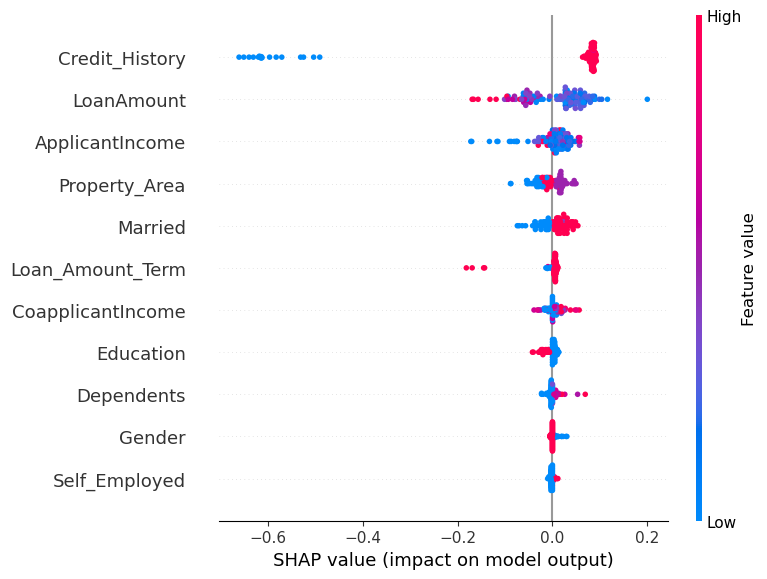

In [96]:
class_id = 1
shap.summary_plot(shap_values[:, :, class_id], X_test, feature_names=X.columns)

Le modèle prend surtout ses décisions sur :

1. Credit_History (facteur principal)
2. LoanAmount
3. ApplicantIncome

Car leur impact est positif


# SHAP value (impact on model output)

In [97]:
i = 2
X_sample = X_test[i]
shap_values_sample = explainer.shap_values(X_sample)[:, 1]

In [98]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1], 
    shap_values_sample, 
    X_sample,
    feature_names=X.columns
)

Le modèle prédit 73 % de probabilité que le prêt soit accepté. \
La base value = 0.7065 \
C’est la probabilité moyenne du modèle avant de considérer les variables. \
Variables qui augmentent la probabilité (rouge) \
Credit_History = 0.4394

# Analyser le meilleur modèle
En utilisant `classification_report`, afficher différentes métriques en train et en test du modèle choisit. Afficher la matrice de confusion en train et en test de ce même modèle. Qu'en concluez-vous sur la qualité de ce modèle?

In [ ]:
y_test_pred = best_model.predict(X_test)
report = classification_report(y_test, y_test_pred)
print(report)

In [ ]:
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)
report = classification_report(y_test, y_pred_test)
print(report)